In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look nice
sns.set_theme(style="whitegrid")

print("Loading the ML-ready dataset...")
df = pd.read_csv('../data/processed/bkk_cleaned.csv')

# Ensure our ML target is numeric
df['seconds_to_next_stop'] = pd.to_numeric(df['seconds_to_next_stop'], errors='coerce')
df['speed_kmh'] = pd.to_numeric(df['vehicle.position.speed'], errors='coerce') * 3.6 # Convert m/s to km/h

print(f"Loaded {len(df)} records.")

Loading the ML-ready dataset...
Loaded 550 records.


1. The Target Distribution

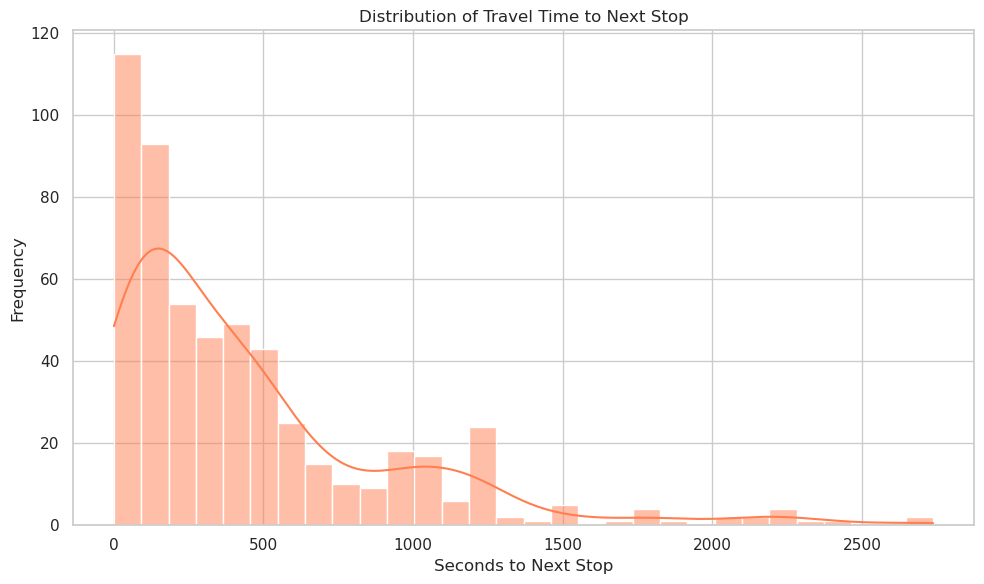

In [58]:
plt.figure(figsize=(10, 6))
sns.histplot(df['seconds_to_next_stop'], bins=30, kde=True, color='coral')
plt.title('Distribution of Travel Time to Next Stop')
plt.xlabel('Seconds to Next Stop')
plt.ylabel('Frequency')
plt.show()

2. The Physics Correlation

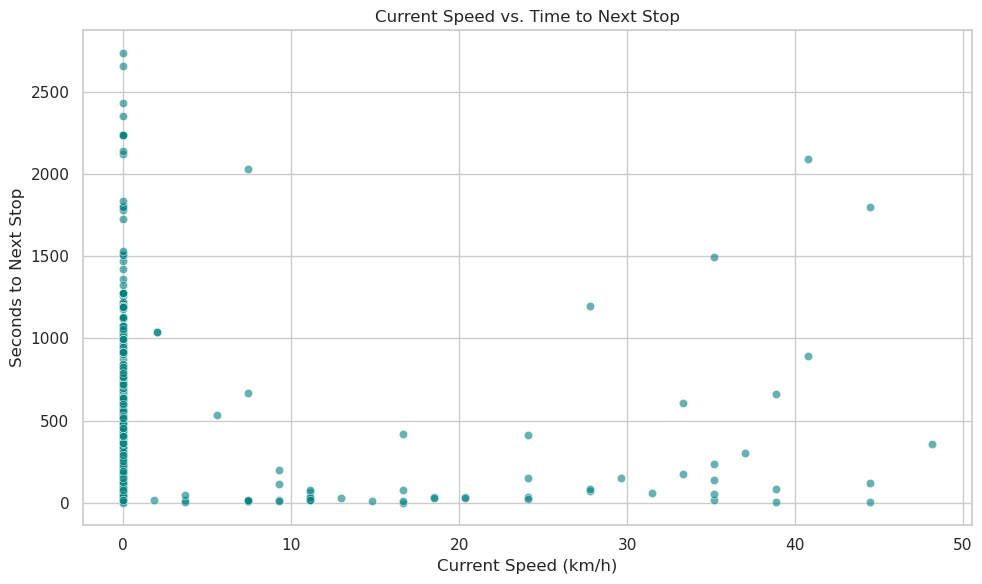

In [59]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='speed_kmh', y='seconds_to_next_stop', data=df, alpha=0.6, color='teal')
plt.title('Current Speed vs. Time to Next Stop')
plt.xlabel('Current Speed (km/h)')
plt.ylabel('Seconds to Next Stop')
plt.show()

In [60]:
# Plotly library usage example
import plotly.express as px

fig = px.scatter(
    df, 
    x='speed_kmh', 
    y='seconds_to_next_stop', 
    title='Current Speed vs. Time to Next Stop',
    labels={
        'speed_kmh': 'Current Speed (km/h)',         # Your custom X-axis label
        'seconds_to_next_stop': 'Seconds to Next Stop' # Your custom Y-axis label
    },
    opacity=0.6,
    color_discrete_sequence=['teal'],
    height=400 
)

fig.show()

3. The Geographic Heatmap

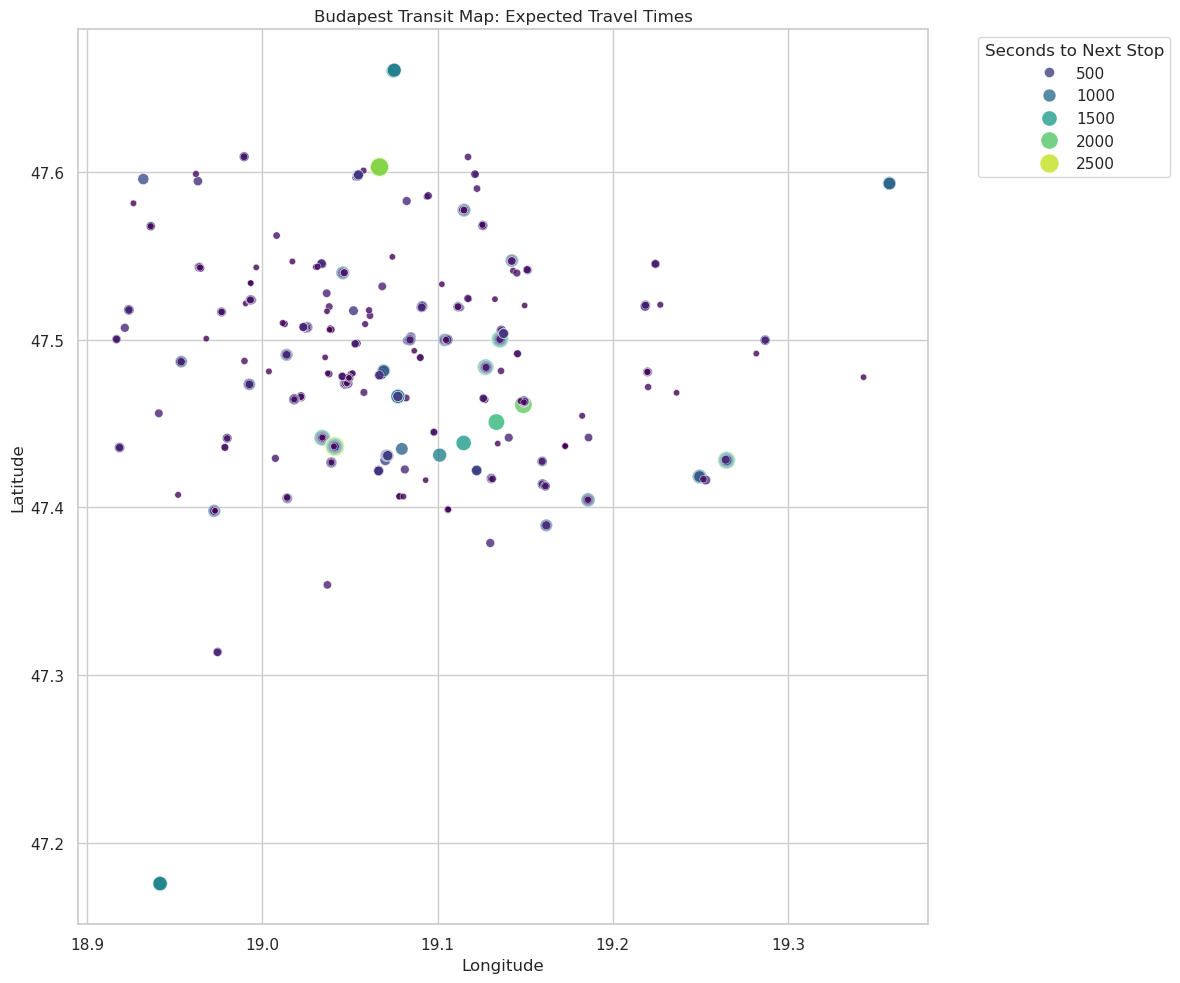

In [61]:
plt.figure(figsize=(12, 10))
# Plotting longitude on X and latitude on Y creates a rough map of the city!
sns.scatterplot(x='longitude', y='latitude', hue='seconds_to_next_stop', 
                palette='viridis', data=df, size='seconds_to_next_stop', sizes=(20, 200), alpha=0.8)

plt.title('Budapest Transit Map: Expected Travel Times')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Seconds to Next Stop', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

4. The "Status" Box Plot

In [62]:
import plotly.express as px

fig = px.box(
    df, 
    x='vehicle.currentStatus', 
    y='seconds_to_next_stop',
    color='vehicle.currentStatus',
    title='Travel Time by Vehicle Status',
    labels={
        'vehicle.currentStatus': 'Current Status',
        'seconds_to_next_stop': 'Seconds to Next Stop'
    },
    points="all" # Shows the underlying data points next to the box
)
fig.show()

5. The "Worst Routes" Bar Chart

In [63]:
# Calculate the average time to next stop for every route
route_stats = df.groupby('vehicle.trip.routeId')['seconds_to_next_stop'].mean().reset_index()

# Sort to find the 15 slowest routes
top_slowest = route_stats.sort_values(by='seconds_to_next_stop', ascending=False).head(15)

fig = px.bar(
    top_slowest, 
    x='vehicle.trip.routeId', 
    y='seconds_to_next_stop',
    title='Top 15 Routes with the Longest Average Time Between Stops',
    labels={
        'vehicle.trip.routeId': 'Route ID',
        'seconds_to_next_stop': 'Average Seconds to Next Stop'
    },
    color='seconds_to_next_stop',
    color_continuous_scale='Reds'
)
# Ensure Plotly treats Route ID as a category, not a continuous number
fig.update_xaxes(type='category') 
fig.show()

6. The "Cascading Delay" Scatter Map

In [64]:
fig = px.density_heatmap(
    df, 
    x='vehicle.currentStopSequence', 
    y='seconds_to_next_stop',
    title='Stop Sequence vs. Time to Next Stop (Heatmap)',
    labels={
        'vehicle.currentStopSequence': 'Stop Number (Progress on Route)',
        'seconds_to_next_stop': 'Seconds to Next Stop'
    },
    color_continuous_scale='Viridis'
)
fig.show()